# Sales KPI Analysis

**Goal:** Provide a business-friendly snapshot of sales performance, margin, and trends.

**Dataset:** Synthetic sales data (2024-2025).


## 1. Setup
We load the dataset and check basic structure.

In [11]:
%pip install pandas matplotlib seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv(r'C:\Users\RD\Documents\Codex\data\sales-kpi-analysis\data\sales_data.csv')
df.head()


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,order_id,order_date,customer_id,product,category,region,channel,quantity,unit_price,unit_cost,discount_pct,gross_revenue,discount_amount,net_revenue,total_cost,profit,margin_pct,order_month
0,ORD100000,2025-10-16,CUST1057,Laptop Pro 14,Electronics,South,Online,3,427.75,250.18,0,1283.25,0.00,1283.25,750.54,532.71,41.51,2025-10
1,ORD100001,2025-08-27,CUST1216,Laptop Pro 14,Electronics,North,Retail,1,390.47,264.09,0,390.47,0.00,390.47,264.09,126.38,32.37,2025-08
2,ORD100002,2025-07-12,CUST1214,Smartphone X,Electronics,North,Online,2,475.03,364.50,10,950.06,95.01,855.05,729.00,126.05,14.74,2025-07
3,ORD100003,2024-10-11,CUST1079,Smartphone X,Electronics,South,Retail,5,557.96,319.82,0,2789.80,0.00,2789.80,1599.10,1190.70,42.68,2024-10
4,ORD100004,2024-02-14,CUST1373,Desk Lamp,Furniture,South,Retail,2,584.68,376.90,5,1169.36,58.47,1110.89,753.80,357.09,32.14,2024-02


## 2. Core KPIs
Key numbers that a business stakeholder cares about.

In [12]:
kpis = {
    'Total Orders': df['order_id'].nunique(),
    'Total Customers': df['customer_id'].nunique(),
    'Total Net Revenue': df['net_revenue'].sum(),
    'Total Profit': df['profit'].sum(),
    'Avg Order Value (AOV)': df['net_revenue'].mean(),
    'Avg Margin %': df['margin_pct'].mean(),
}
pd.DataFrame(kpis, index=['Value']).T


,Value
Total Orders,2.000000e+03
Total Customers,4.920000e+02
Total Net Revenue,1.792184e+06
Total Profit,5.186613e+05
Avg Order Value (AOV),8.960921e+02
Avg Margin %,2.817526e+01


## 3. Monthly Trend
Revenue and profit over time.

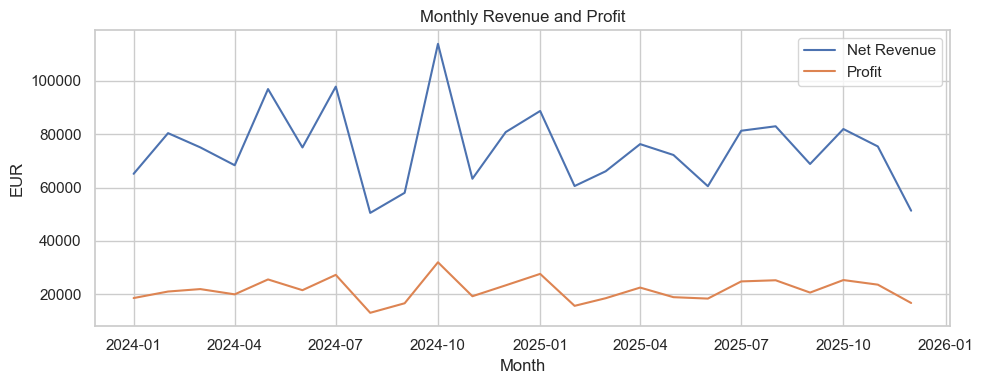

In [13]:
monthly = df.groupby('order_month')[['net_revenue', 'profit']].sum().reset_index()
monthly['order_month'] = pd.to_datetime(monthly['order_month'])
monthly = monthly.sort_values('order_month')

plt.figure(figsize=(10, 4))
plt.plot(monthly['order_month'], monthly['net_revenue'], label='Net Revenue')
plt.plot(monthly['order_month'], monthly['profit'], label='Profit')
plt.title('Monthly Revenue and Profit')
plt.xlabel('Month')
plt.ylabel('EUR')
plt.legend()
plt.tight_layout()
plt.show()


## 4. Top Products and Categories
Which products and categories drive revenue.

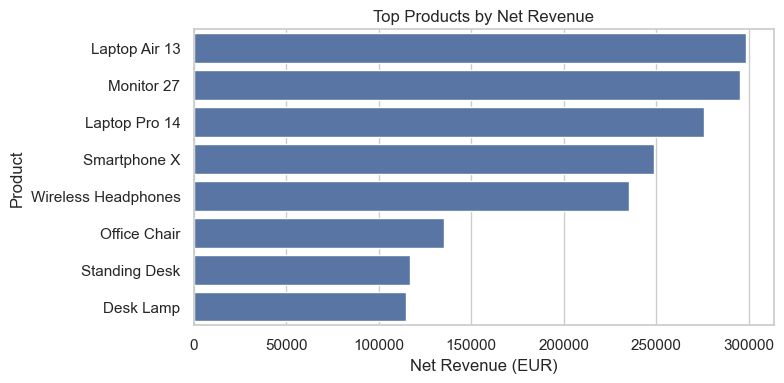

,net_revenue,profit
category,,
Electronics,1353654.03,395076.65
Furniture,366556.99,103592.91
Accessories,56159.18,15440.76
Stationery,15813.94,4550.95


In [14]:
top_products = df.groupby('product')['net_revenue'].sum().sort_values(ascending=False).head(8)
plt.figure(figsize=(8, 4))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Top Products by Net Revenue')
plt.xlabel('Net Revenue (EUR)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

cat = df.groupby('category')[['net_revenue','profit']].sum().sort_values('net_revenue', ascending=False)
cat


## 5. Regional and Channel Performance
Compare revenue and margins across regions and sales channels.

In [15]:
region = df.groupby('region')[['net_revenue','profit']].sum().sort_values('net_revenue', ascending=False)
channel = df.groupby('channel')[['net_revenue','profit']].sum().sort_values('net_revenue', ascending=False)
region, channel


(         net_revenue     profit
 region                         
 North      632550.23  181491.15
 Center     547179.35  157776.48
 South      457673.50  134652.03
 Islands    154781.06   44741.61,
            net_revenue     profit
 channel                          
 Online       954639.31  276005.17
 Retail       578175.32  167599.31
 Wholesale    259369.51   75056.79)

## 6. Discount vs Margin
Quick check: do higher discounts hurt profitability?

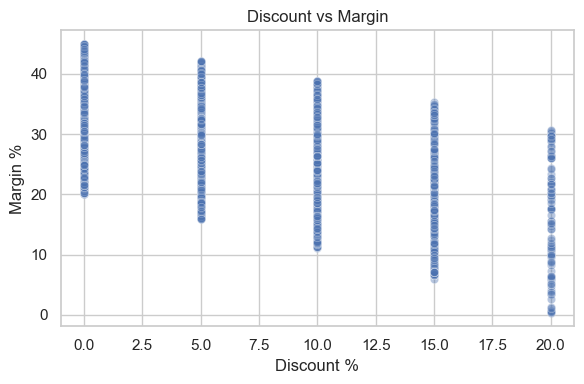

In [16]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='discount_pct', y='margin_pct', alpha=0.4)
plt.title('Discount vs Margin')
plt.xlabel('Discount %')
plt.ylabel('Margin %')
plt.tight_layout()
plt.show()


## 7. Executive Summary (Auto)
This section generates concise, business?friendly insights based on the data.


### Executive Summary (Insights)
- I primi 3 prodotti generano circa il **48%** dei ricavi totali (≈ 869k su 1.79M).
- La regione **North** è quella con il maggior contributo di profitto (≈ 181k).
- Picchi di ricavi in **ottobre 2024** e **luglio 2024**; cali in **agosto 2024** e **dicembre 2025**.
- La marginalità media scende al crescere dello sconto (dal **32.4%** a **16.4%**).
- Implicazione: proteggere i margini sugli sconti elevati e concentrare lo sforzo commerciale sui prodotti top.


In [17]:
# Compute a few headline insights
total_rev = df['net_revenue'].sum()
top_products = df.groupby('product')['net_revenue'].sum().sort_values(ascending=False)
top3_share = (top_products.head(3).sum() / total_rev) * 100

region = df.groupby('region')[['net_revenue','profit']].sum().sort_values('profit', ascending=False)
top_region = region.index[0]

discount_margin = df.groupby('discount_pct')['margin_pct'].mean().sort_index()

print('Executive Summary')
print('-' * 60)
print(f'Top 3 products generate ~{top3_share:.1f}% of total net revenue.')
print(f'Highest profit region: {top_region}.')
print('Average margin by discount level:')
print(discount_margin)


Executive Summary
------------------------------------------------------------
Top 3 products generate ~48.5% of total net revenue.
Highest profit region: North.
Average margin by discount level:
discount_pct
0     32.398654
5     28.837775
10    25.139355
15    19.929251
20    16.362871
Name: margin_pct, dtype: float64


## 7. Business Summary (Template)
Write 3-5 bullet insights based on the charts and KPIs.

Examples:
- The top 3 products contribute X% of total revenue.
- The North region is the main driver of profit.
- Higher discounts show lower margins on average.
